In [13]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline
import math
import seaborn as sns
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [14]:
df=pd.read_csv('fiverr_data.csv')
df.shape

(458798, 53)

In [3]:
# dropping irrelevant column
df=df.drop('user_id', axis=1)
df[df.duplicated()]

,label,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X42,X43,X44,X45,X46,X47,X48,X49,X50,X51
4801,0,13534,14,36,1,9,1,1,21,26,...,0,0,0,0,0,0,0,0,0,0
5367,0,4950,78,36,1,9,1,1,22,26,...,0,0,0,0,0,0,0,0,0,0
8057,0,1,213,36,1,9,1,1,21,26,...,0,0,0,0,0,0,0,0,0,0
9119,0,4543,213,36,1,9,1,1,22,26,...,0,0,0,0,0,0,0,0,0,0
9422,0,1,213,36,1,9,1,1,21,26,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405137,0,4815,213,13,3,17,4,8,15,14,...,0,0,0,0,0,0,0,0,1,0
405865,0,4815,213,13,3,17,4,8,15,14,...,0,0,0,0,0,0,0,0,1,0
411623,0,5715,213,13,3,17,4,8,15,36,...,0,0,0,0,0,0,0,0,1,0
412396,0,12439,212,13,3,17,4,8,15,36,...,0,0,0,0,0,0,0,0,1,0


In [15]:
# Drop duplicates
df=df.drop_duplicates()

In [16]:
df.isna().sum()[df.isna().sum() > 0]

X13    6
dtype: int64

In [17]:
# Fill na with mode:
df['X13'] = df['X13'].fillna(df['X13'].mode()[0])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 453449 entries, 0 to 458797
Data columns (total 52 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   label   453449 non-null  int64
 1   X1      453449 non-null  int64
 2   X2      453449 non-null  int64
 3   X3      453449 non-null  int64
 4   X4      453449 non-null  int64
 5   X5      453449 non-null  int64
 6   X6      453449 non-null  int64
 7   X7      453449 non-null  int64
 8   X8      453449 non-null  int64
 9   X9      453449 non-null  int64
 10  X10     453449 non-null  int64
 11  X11     453449 non-null  int64
 12  X12     453449 non-null  int64
 13  X13     453449 non-null  int64
 14  X14     453449 non-null  int64
 15  X15     453449 non-null  int64
 16  X16     453449 non-null  int64
 17  X17     453449 non-null  int64
 18  X18     453449 non-null  int64
 19  X19     453449 non-null  int64
 20  X20     453449 non-null  int64
 21  X21     453449 non-null  int64
 22  X22     453449 non-null  

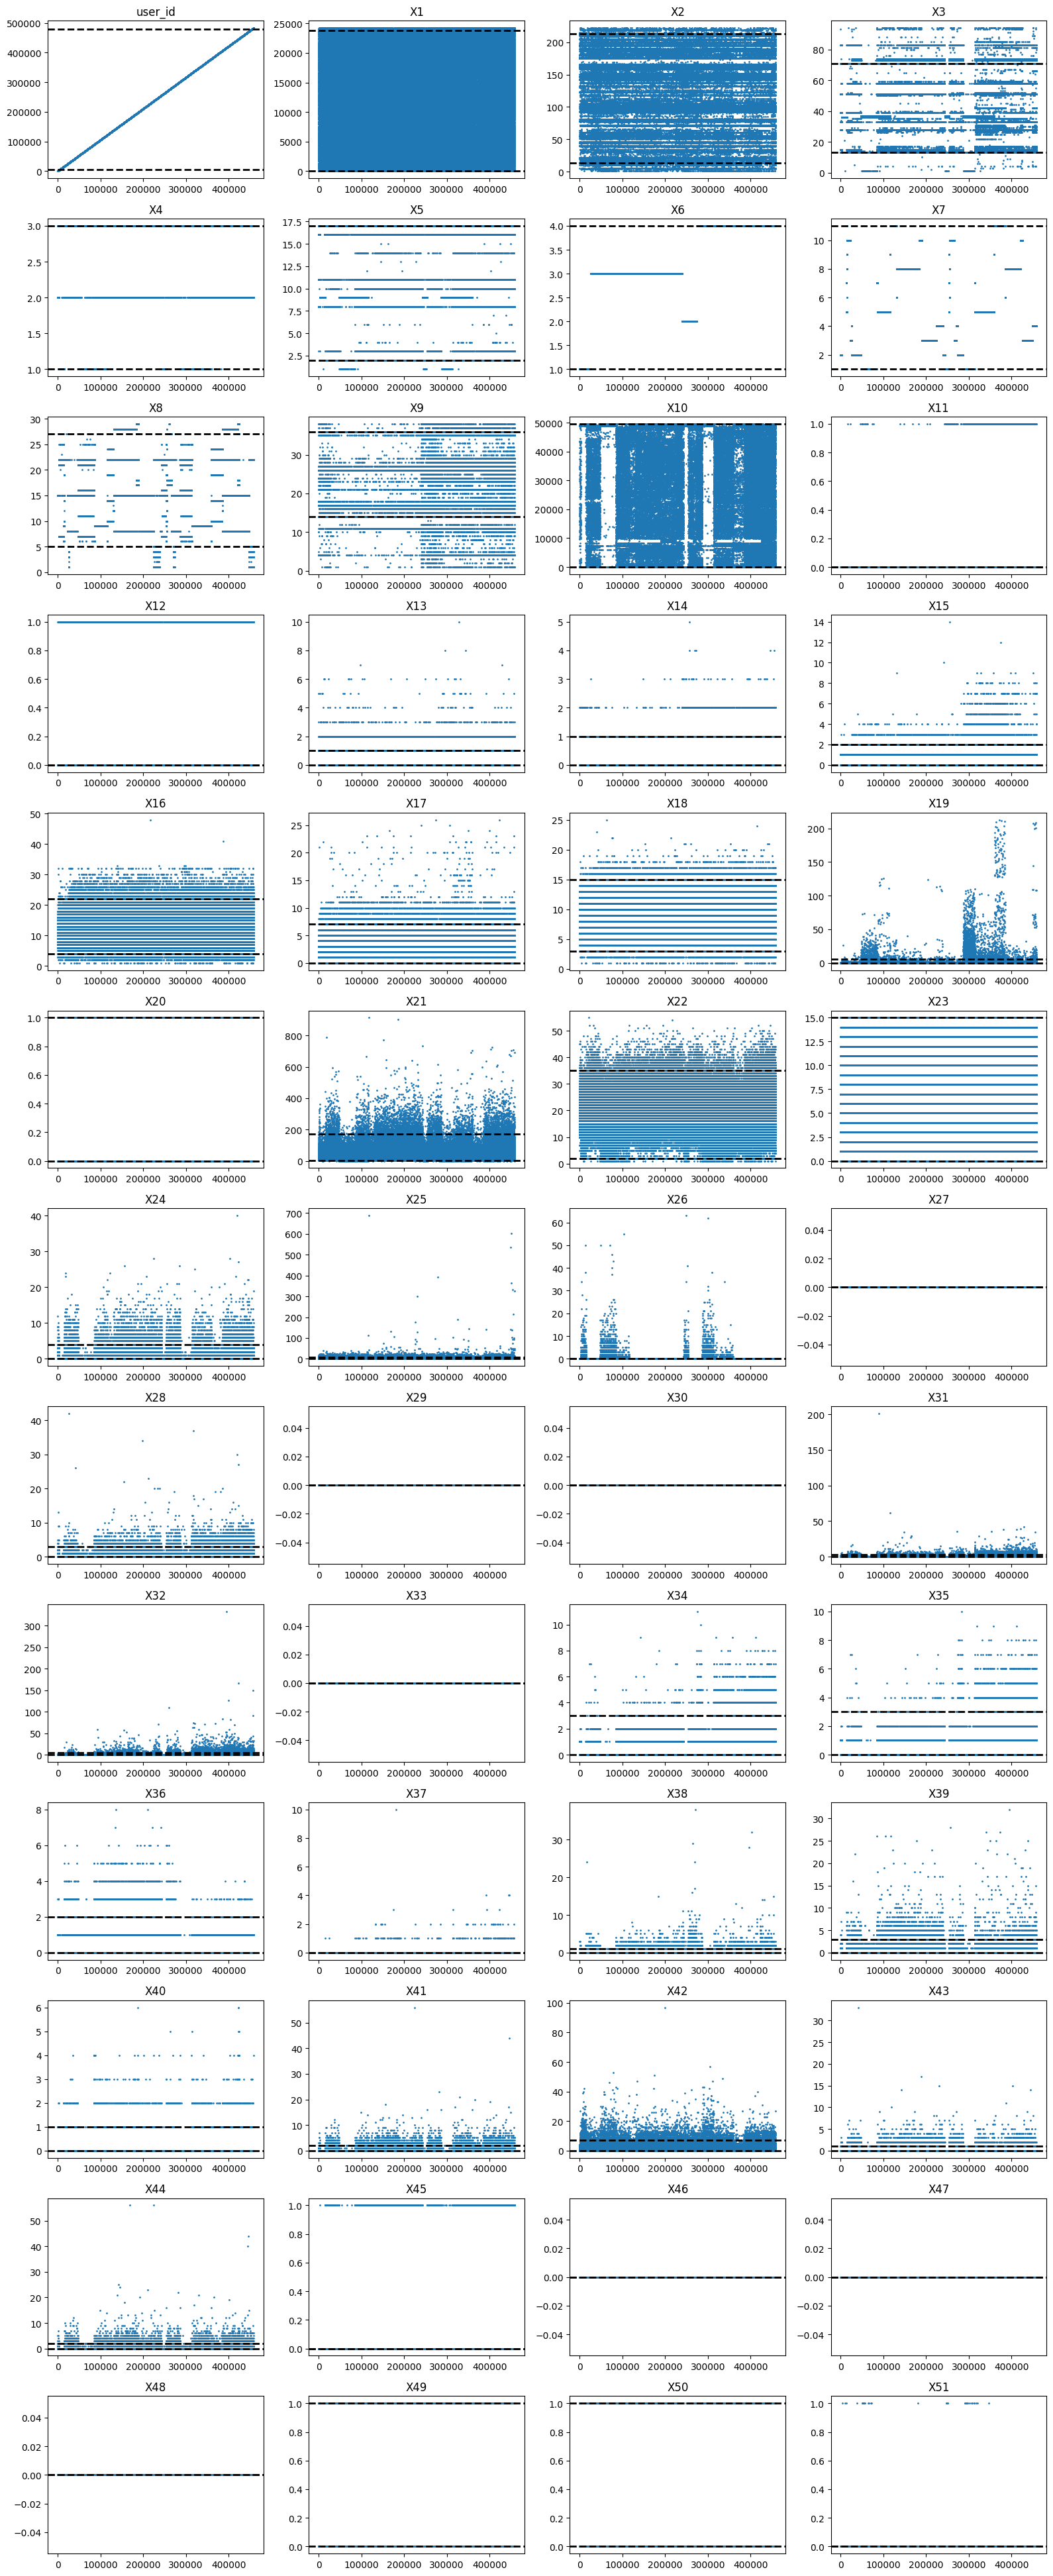

In [18]:
# Draw a graph to detect percentiles above 99 percentile and below 1 percentile
X=df.drop('label', axis=1)
feature_cols=X.columns
n_plots = len(feature_cols)
plots_per_row = 4
n_rows = math.ceil(n_plots / plots_per_row)


fig, axes = plt.subplots(
    n_rows,
    plots_per_row,
    figsize=(plots_per_row * 4, n_rows * 3)
)
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    z=df[col]
    x = np.arange(len(z))
    p1 = np.percentile(z,1)
    p99 = np.percentile(z,99)
    axes[i].scatter(x,z,s=1)
    axes[i].axhline(p1, linestyle='--', linewidth=2, label='1st percentile', color='black')
    axes[i].axhline(p99, linestyle='--', linewidth=2, label='99th percentile', color='black')
    axes[i].set_title(col)
    

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [7]:
#Treating outliers at 1 and 99 quantile respectively.
def list_treat_outliers_quantile(df, col, lower_quantile, upper_quantile):

    lower = df[col].quantile(lower_quantile)
    upper = df[col].quantile(upper_quantile)
    df_outliers=df[(df[col]<lower) | (df[col]>upper)]
    outlier_count=df_outliers.shape[0]
    total_count=df.shape[0]
    df[col] = df[col].clip(lower, upper)
    ratio=outlier_count/total_count


for col in df.select_dtypes(include='number').columns:
    list_treat_outliers_quantile(df, col, .01,.99)

In [8]:
# Find duplicate columns.
def find_duplicate_columns(df):
    duplicates = {}
    seen = {}

    for col in df.columns:
        col_values = tuple(df[col])

        if col_values in seen:
            duplicates.setdefault(seen[col_values], set()).add(col)
        else:
            seen[col_values] = col

    return duplicates

duplicate_cols=find_duplicate_columns(df)
duplicate_cols

{'X11': {'X12',
  'X26',
  'X27',
  'X29',
  'X30',
  'X33',
  'X37',
  'X45',
  'X46',
  'X47',
  'X48',
  'X51'}}

In [9]:
# Removed duplicate columns
df=df.drop(columns=['X12','X26','X27','X29','X30','X33','X37','X45','X46','X47','X48','X51'], axis=1)

In [10]:
df.shape

(453449, 40)

In [11]:
# Split data into X and Y
# Changing type for X13 from float to int
df['X13']=df['X13'].astype(int)
X=df.drop('label', axis=1)
y=df['label']

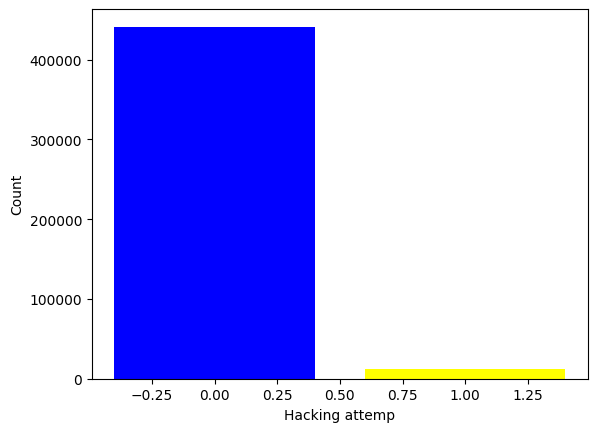

In [12]:
# Draw target classes bar charts:
class_counts = y.value_counts()

plt.bar(class_counts.index, class_counts.values, color=['blue','yellow'])
plt.xlabel("Hacking attemp")
plt.ylabel("Count")
plt.show()

In [164]:
y.value_counts()

label
0    441171
1     12278
Name: count, dtype: int64

In [8]:
# Train and test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=3)

In [12]:
# find skewness
X.skew().sort_values(ascending=False)

X40    7.288658
X14    7.258366
X19    6.613265
X41    5.202453
X43    5.084501
X44    4.841406
X24    4.289574
X42    3.462408
X38    3.185653
X25    3.099357
X13    3.059048
X21    2.762938
X15    2.451347
X32    2.436434
X31    1.687524
X28    1.683478
X35    1.632148
X34    1.569500
X23    1.540895
X9     1.488816
X39    1.326448
X3     1.066996
X17    1.018078
X49    0.856139
X22    0.823390
X36    0.437988
X7     0.395320
X10    0.340785
X16    0.239871
X1     0.045218
X11    0.000000
X8    -0.004331
X18   -0.020060
X50   -0.027953
X20   -0.073306
X5    -0.470912
X2    -0.752911
X4    -0.850406
X6    -1.041748
dtype: float64

In [9]:
# Treating skewness
skewed_cols=['X3','X6','X9','X13','X14','X15','X17','X19','X21','X23','X24','X25','X28','X31','X32',
             'X34','X35','X38','X39','X40','X41','X42','X43','X44']
from sklearn.preprocessing import PowerTransformer

# Apply PowerTransformer to skewed columns
pt = PowerTransformer(method='yeo-johnson')
X_train[skewed_cols] = pt.fit_transform(X_train[skewed_cols])
X_test[skewed_cols] = pt.transform(X_test[skewed_cols])

In [10]:
# Scale X_train and X_test using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Performing oversampling of minority class
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.9, random_state=3)
X_train_smt, y_train_smt = smote.fit_resample(X_train, y_train)
display(y_train_smt.value_counts())

label
0    334884
1    301395
Name: count, dtype: int64

In [ ]:
# Apply PCA on X features. fit_transform on X_train and transform on X_test to prevent Data leakage.

# We are not doing PCA since it results in poor Precision and recall matrix on test data.

# from sklearn.decomposition import PCA
# pca = PCA(n_components=2, random_state=2)

# X_train_pca = pca.fit_transform(X_train)
# X_train_pca = pd.DataFrame(
#     X_train_pca,
#     columns=[f"PC{i+1}" for i in range(X_train_pca.shape[1])]
# )

# X_test_pca = pca.transform(X_test)
# X_test_pca = pd.DataFrame(
#     X_test_pca,
#     columns=[f"PC{i+1}" for i in range(X_test_pca.shape[1])]
# )

In [169]:
y_train.value_counts()

label
0    330898
1      9188
Name: count, dtype: int64

In [ ]:
# Utility method to fit model on train and then calculate accuracy, precisio, recall etc for both train
# and test datasets
def print_stats(model, model_name, X_train,X_test, y_train,y_test):
    model.fit(X_train, y_train)

    # y_prob = model.predict_proba(X_test)[:, 1]
    # y_pred = (y_prob > 0.9).astype(int)
    y_pred = model.predict(X_test)
    print(f"{model_name} : Accuracy: test", accuracy_score(y_test, y_pred))
    print("\nConfusion Matrix:test\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:test\n", classification_report(y_test, y_pred))

    # y_prob = model.predict_proba(X_train)[:, 1]
    # y_pred = (y_prob > 0.9).astype(int)
    y_pred = model.predict(X_train)
    print(f"{model_name} : Accuracy:train", accuracy_score(y_train, y_pred))
    print("\nConfusion Matrix:train\n", confusion_matrix(y_train, y_pred))
    print("\nClassification Report:train\n", classification_report(y_train, y_pred))

In [20]:
#Logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

lr = LogisticRegression(class_weight='balanced')

cv = StratifiedKFold(n_splits=5,shuffle=True, random_state=7)
scores = cross_val_score(lr,X_train_smt,y_train_smt,cv=cv,scoring='accuracy')
display("Logistic regression: Cross Validation Accuracy scores:", scores)
display("Mean Accuracy:", np.mean(scores))
display("============================================================")
print_stats(lr,"Logistic Regression",X_train_smt, X_test, y_train_smt,y_test)

'Logistic regression: Cross Validation Accuracy scores:'

array([0.86192362, 0.86303592, 0.86081708, 0.86248718, 0.86353695])

'Mean Accuracy:'

np.float64(0.8623601499532828)

'============================================================'

Logistic Regression : Accuracy: test 0.8707955858613481

Confusion Matrix:test
 [[96117 14156]
 [  491  2599]]

Classification Report:test
               precision    recall  f1-score   support

           0       0.99      0.87      0.93    110273
           1       0.16      0.84      0.26      3090

    accuracy                           0.87    113363
   macro avg       0.58      0.86      0.60    113363
weighted avg       0.97      0.87      0.91    113363

Logistic Regression : Accuracy:train 0.8623967323359408

Confusion Matrix:train
 [[288339  42559]
 [ 43953 253855]]

Classification Report:train
               precision    recall  f1-score   support

           0       0.87      0.87      0.87    330898
           1       0.86      0.85      0.85    297808

    accuracy                           0.86    628706
   macro avg       0.86      0.86      0.86    628706
weighted avg       0.86      0.86      0.86    628706



In [171]:
# XGBoost
import xgboost as xgb

# xgb = xgb.XGBClassifier(objective='binary:logistic', n_estimators=300, max_depth=3, 
#                           learning_rate=0.05, random_state=7)
xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)

cv = StratifiedKFold(n_splits=10,shuffle=True, random_state=7)
scores = cross_val_score(xgb,X_train_smt,y_train_smt,cv=cv,scoring='accuracy')
display("XGBoost: Cross Validation Accuracy scores:", scores)
display("Mean Accuracy:", np.mean(scores))
display("============================================================")

print_stats(xgb,"XGBoost",X_train_smt, X_test, y_train_smt,y_test)

'XGBoost: Cross Validation Accuracy scores:'

array([0.96744127, 0.96790253, 0.96798206, 0.96822064, 0.96771166,
       0.96858647, 0.96903133, 0.97035152, 0.96971529, 0.96939717])

'Mean Accuracy:'

np.float64(0.968633994202904)

'============================================================'

XGBoost : Accuracy: test 0.9645122306219842

Confusion Matrix:test
 [[107029   3244]
 [   779   2311]]

Classification Report:test
               precision    recall  f1-score   support

           0       0.99      0.97      0.98    110273
           1       0.42      0.75      0.53      3090

    accuracy                           0.96    113363
   macro avg       0.70      0.86      0.76    113363
weighted avg       0.98      0.96      0.97    113363

XGBoost : Accuracy:train 0.969341790916581

Confusion Matrix:train
 [[321371   9527]
 [  9748 288060]]

Classification Report:train
               precision    recall  f1-score   support

           0       0.97      0.97      0.97    330898
           1       0.97      0.97      0.97    297808

    accuracy                           0.97    628706
   macro avg       0.97      0.97      0.97    628706
weighted avg       0.97      0.97      0.97    628706



In [104]:
y_test.value_counts()

label
0    110273
1      3090
Name: count, dtype: int64

In [ ]:
# Random Forest
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=2, calss_weight=['balanced']) 

# param_grid = {
#     'n_estimators': [50, 100, 150],
#     'max_depth': [None, 7],
#     'min_samples_split': [None, 10],
#     'min_samples_leaf': [None, 4]
# }  

param_grid = {
    'n_estimators': [150],
    'min_samples_split': [5],
    'min_samples_leaf': [4]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=3
) 
grid_search.fit(X_train_smt, y_train_smt)
best_rf = grid_search.best_estimator_
print('Found best rf')
cv = StratifiedKFold(n_splits=5,shuffle=True, random_state=7)
scores = cross_val_score(best_rf,X_train_smt,y_train_smt,cv=cv,scoring='accuracy')
display("Random Forest: Cross Validation Accuracy scores:", scores)
display("Mean Accuracy:", np.mean(scores))
display("============================================================")

print_stats(best_rf,"Random Forest",X_train_smt, X_test, y_train_smt,y_test)

Found best rf


'Random Forest: Cross Validation Accuracy scores:'

array([0.98890585, 0.98842064, 0.98840474, 0.98870695, 0.98947042])

'Mean Accuracy:'

np.float64(0.9887817197161549)

'============================================================'

Random Forest : Accuracy: test 0.9809020579907024

Confusion Matrix:test
 [[109093   1180]
 [   985   2105]]

Classification Report:test
               precision    recall  f1-score   support

           0       0.99      0.99      0.99    110273
           1       0.64      0.68      0.66      3090

    accuracy                           0.98    113363
   macro avg       0.82      0.84      0.83    113363
weighted avg       0.98      0.98      0.98    113363

Random Forest : Accuracy:train 0.9934436763765576

Confusion Matrix:train
 [[328577   2321]
 [  1801 296007]]

Classification Report:train
               precision    recall  f1-score   support

           0       0.99      0.99      0.99    330898
           1       0.99      0.99      0.99    297808

    accuracy                           0.99    628706
   macro avg       0.99      0.99      0.99    628706
weighted avg       0.99      0.99      0.99    628706



In [27]:
# Decision Tree 
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

dt = DecisionTreeClassifier(random_state=42)
param_grid = {
    'max_depth': [7],
    'min_samples_split': [5,10],
    'min_samples_leaf': [5,10],
    'ccp_alpha': [0.0, 0.05, 0.1]
}

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,                        
    scoring='f1',
    n_jobs=3)

grid_search.fit(X_train_smt, y_train_smt)
best_dt = grid_search.best_estimator_

cv = StratifiedKFold(n_splits=5,shuffle=True, random_state=7)
scores = cross_val_score(best_dt,X_train_smt,y_train_smt,cv=cv,scoring='accuracy')
display("Decision Tree: Cross Validation Accuracy scores:", scores)
display("Mean Accuracy:", np.mean(scores))
display("============================================================")

print_stats(best_dt,"Decision Tree",X_train_smt, X_test, y_train_smt,y_test)

'Decision Tree: Cross Validation Accuracy scores:'

array([0.9092825 , 0.89865676, 0.90782641, 0.90993391, 0.89810006])

'Mean Accuracy:'

np.float64(0.90475992829308)

'============================================================'

Decision Tree : Accuracy: test 0.9223203337949772

Confusion Matrix:test
 [[102165   8108]
 [   698   2392]]

Classification Report:test
               precision    recall  f1-score   support

           0       0.99      0.93      0.96    110273
           1       0.23      0.77      0.35      3090

    accuracy                           0.92    113363
   macro avg       0.61      0.85      0.66    113363
weighted avg       0.97      0.92      0.94    113363

Decision Tree : Accuracy:train 0.9094505221836597

Confusion Matrix:train
 [[306908  23990]
 [ 32939 264869]]

Classification Report:train
               precision    recall  f1-score   support

           0       0.90      0.93      0.92    330898
           1       0.92      0.89      0.90    297808

    accuracy                           0.91    628706
   macro avg       0.91      0.91      0.91    628706
weighted avg       0.91      0.91      0.91    628706



In [ ]:

{'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 150}
{'min_samples_leaf': 10, 'min_samples_split': 5, 'n_estimators': 100}

In [13]:
_, X_test_smt, _, y_test_smt = train_test_split(X_train_smt, y_train_smt, 
                                                    test_size=0.01, random_state=3)
X_test_smt.shape

(6363, 40)

In [ ]:
# SVM. It was taking tool long. Even for around 1 lac record it kept running for 2 hours and did still
# did not complete. Skipping this algorithm.
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
svm_model = SVC( C=1.0, gamma='scale')

cv = StratifiedKFold(n_splits=5,shuffle=True, random_state=7)
scores = cross_val_score(svm_model,X_test_smt,y_test_smt,cv=cv,scoring='accuracy')
display("SVC: Cross Validation Accuracy scores:", scores)
display("Mean Accuracy:", np.mean(scores))
display("============================================================")

print_stats(svm_model,"SVC",X_train_smt, X_test, y_train_smt,y_test)

'SVC: Cross Validation Accuracy scores:'

array([0.89787903, 0.89002357, 0.88138256, 0.87185535, 0.88443396])

'Mean Accuracy:'

np.float64(0.8851148922715124)

'============================================================'

In [24]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

cv = StratifiedKFold(n_splits=5,shuffle=True, random_state=7)
scores = cross_val_score(knn,X_train_smt,y_train_smt,cv=cv,scoring='accuracy')
display("KNN: Cross Validation Accuracy scores:", scores)
display("Mean Accuracy:", np.mean(scores))
display("============================================================")

print_stats(knn,"KNN",X_train_smt, X_test, y_train_smt,y_test)

'KNN: Cross Validation Accuracy scores:'

array([0.96535764, 0.96559595, 0.96515854, 0.96608902, 0.96585839])

'Mean Accuracy:'

np.float64(0.9656119080369377)

'============================================================'

KNN : Accuracy: test 0.938419060892884

Confusion Matrix:test
 [[104069   6204]
 [   777   2313]]

Classification Report:test
               precision    recall  f1-score   support

           0       0.99      0.94      0.97    110273
           1       0.27      0.75      0.40      3090

    accuracy                           0.94    113363
   macro avg       0.63      0.85      0.68    113363
weighted avg       0.97      0.94      0.95    113363

KNN : Accuracy:train 0.9776381965497387

Confusion Matrix:train
 [[316954  13944]
 [   115 297693]]

Classification Report:train
               precision    recall  f1-score   support

           0       1.00      0.96      0.98    330898
           1       0.96      1.00      0.98    297808

    accuracy                           0.98    628706
   macro avg       0.98      0.98      0.98    628706
weighted avg       0.98      0.98      0.98    628706



In [26]:
from sklearn.naive_bayes import GaussianNB

gaussianNB = GaussianNB(priors=[0.97, 0.03], var_smoothing=1e-8)
cv = StratifiedKFold(n_splits=5,shuffle=True, random_state=7)
scores = cross_val_score(gaussianNB,X_train_smt,y_train_smt,cv=cv,scoring='accuracy')
display("GaussianNB: Cross Validation Accuracy scores:", scores)
display("Mean Accuracy:", np.mean(scores))
display("============================================================")

print_stats(gaussianNB,"GaussianNB",X_train_smt, X_test, y_train_smt,y_test)

'GaussianNB: Cross Validation Accuracy scores:'

array([0.78909195, 0.79080809, 0.79017186, 0.78858924, 0.78983784])

'Mean Accuracy:'

np.float64(0.7896997970559323)

'============================================================'

GaussianNB : Accuracy: test 0.7123047202349974

Confusion Matrix:test
 [[78029 32244]
 [  370  2720]]

Classification Report:test
               precision    recall  f1-score   support

           0       1.00      0.71      0.83    110273
           1       0.08      0.88      0.14      3090

    accuracy                           0.71    113363
   macro avg       0.54      0.79      0.49    113363
weighted avg       0.97      0.71      0.81    113363

GaussianNB : Accuracy:train 0.7897427414403553

Confusion Matrix:train
 [[233447  97451]
 [ 34739 263069]]

Classification Report:train
               precision    recall  f1-score   support

           0       0.87      0.71      0.78    330898
           1       0.73      0.88      0.80    297808

    accuracy                           0.79    628706
   macro avg       0.80      0.79      0.79    628706
weighted avg       0.80      0.79      0.79    628706

